<img src="./logo_UNSAM.jpg" align="right" width="150" /> 

#### Análisis y Procesamiento de Señales

# Trabajo Práctico Nº5
#### Jeremias Martin Pantozzi

## 1. Introducción Teórica

El análisis en el dominio de la frecuencia es una herramienta fundamental en el procesamiento de señales digitales (DSP), ya que permite caracterizar el contenido espectral de señales reales, las cuales suelen estar contaminadas con ruido o presentar comportamientos estocásticos. En este trabajo práctico se analizan tres tipos de señales físicas: un Electrocardiograma (ECG), una Pletismografía (PPG) y registros de Audio (voz y silbido). 

Para caracterizar estas señales, nos enfocaremos en dos métricas clave: la estimación de la Densidad Espectral de Potencia (PSD) y el cálculo de su Ancho de Banda (BW) efectivo.

### Densidad Espectral de Potencia (PSD)

La Densidad Espectral de Potencia, denotada frecuentemente como $S_{xx}(f)$, describe cómo se distribuye la potencia de una señal a lo largo de las distintas frecuencias. Para señales aleatorias estacionarias, el Teorema de Wiener-Khinchin establece que la PSD es la Transformada de Fourier de la función de autocorrelación de la señal, $R_{xx}(\tau)$:

$$S_{xx}(f)=\sum_{\tau=-\infty}^{\infty}R_{xx}(\tau)e^{-j2\pi f\tau}$$

Dado que en la práctica contamos con un registro finito de datos, no podemos calcular la PSD real, sino que debemos realizar una **estimación** de la misma utilizando métodos no paramétricos.

### Métodos No Paramétricos de Estimación Espectral

Para este análisis, se pueden emplear distintos estimadores clásicos:

* **Periodograma Ventaneado:** Se basa en calcular la magnitud al cuadrado de la Transformada Discreta de Fourier (DFT) de la señal multiplicada por una ventana $w[n]$ (para reducir el fenómeno de *leakage* o fuga espectral). Si bien es asintóticamente insesgado, su varianza no disminuye al aumentar la cantidad de muestras, lo que lo hace un estimador inconsistente.
* **Método de Welch:** Es una mejora robusta sobre el periodograma. Consiste en dividir la señal original en segmentos superpuestos (overlap), aplicar una ventana a cada segmento, calcular sus periodogramas individuales y finalmente promediarlos. Este promediado reduce significativamente la varianza de la estimación a expensas de una menor resolución frecuencial.
* **Método de Blackman-Tukey:** Consiste en estimar primero la secuencia de autocorrelación de la señal, aplicarle una ventana temporal para suavizarla, y luego calcular su Transformada de Fourier.

En este trabajo, optaremos principalmente por el **Método de Welch**, ya que ofrece un excelente compromiso entre reducción de varianza (suavizado del ruido) y resolución, resultando ideal para aislar las componentes útiles en señales contaminadas.

#### Parámetros del Método de Welch en Python (`scipy.signal.welch`)

Para la implementación práctica de la estimación espectral, se utilizó la función `welch` de la librería `scipy.signal`. Es fundamental comprender el rol de cada parámetro configurado, ya que definen el compromiso entre resolución frecuencial y varianza del estimador:

* **La señal (`x`):** Es el arreglo unidimensional que contiene las muestras del registro temporal (por ejemplo, el vector del ECG o del audio).
* **Frecuencia de muestreo (`fs`):** Frecuencia a la que se digitalizó la señal original (en Hz). Es estrictamente necesaria para que el algoritmo pueda escalar correctamente el eje X en frecuencias reales. Si se omite, el resultado se expresa en frecuencias normalizadas (de 0 a 0.5).
* **La ventana (`window='hamming'`):** El método de Welch divide la señal en segmentos superpuestos. Para evitar el truncamiento abrupto en los bordes de cada segmento (lo que genera *leakage* o fuga espectral), se multiplica cada uno por una ventana de Hamming. Esta función atenúa los extremos hacia cero, suavizando la transición y eliminando artefactos de alta frecuencia.
* **Puntos por segmento (`nperseg`):** Define la longitud (en cantidad de muestras) de cada segmento en los que se divide la señal. Este parámetro controla el compromiso fundamental de la estimación espectral:
    * Un `nperseg` **grande** proporciona una alta *resolución frecuencial* (permite distinguir frecuencias muy cercanas), pero genera menos segmentos para promediar, resultando en un espectro con mayor varianza (curva "rugosa").
    * Un `nperseg` **chico** genera muchos segmentos. Al promediarlos, la varianza disminuye drásticamente (curva "suave"), pero a costa de perder resolución frecuencial (los picos se ensanchan).
* **Zero-Padding (`nfft`):** Fija la cantidad de puntos utilizados para la Transformada Rápida de Fourier (FFT). Al definir un `nfft` mayor que `nperseg`, el algoritmo rellena los segmentos con ceros antes de pasar al dominio de la frecuencia. Esto actúa como una interpolación en el dominio frecuencial: no agrega información nueva ni mejora la resolución real, pero incrementa la densidad de puntos en el gráfico, permitiendo calcular con mayor exactitud los cruces de umbrales de energía (como el cálculo del ancho de banda al 95%).
* **Escala (`scaling='spectrum'`):** Define la representación del eje Y. Al utilizar `'spectrum'`, el valor en cada bin frecuencial representa la **potencia** absoluta de esa componente. Esto es ideal para señales con componentes determinísticas fuertes, a diferencia de `'density'`, que expresa el eje en Densidad Espectral de Potencia (potencia por unidad de frecuencia), más adecuado para analizar ruido de fondo puro.

### Estimación del Ancho de Banda (BW)

El ancho de banda teórico de una señal de tiempo discreto está limitado por la frecuencia de Nyquist. Sin embargo, el **ancho de banda efectivo** se define empíricamente como el rango de frecuencias que concentra la mayor parte de la energía útil de la señal. En este trabajo, adoptaremos el criterio del **95% de la potencia total**, ya que se asume señales sin ruido.

Matemáticamente, definimos la función de potencia acumulada normalizada integrando (o sumando, en tiempo discreto) la PSD estimada en escala lineal:


A partir de esta función, el cálculo del BW depende de la naturaleza de la señal:

1. **Señales Pasa-bajos (Ej. ECG, PPG):** La energía comienza en DC (0 Hz). El ancho de banda abarca desde 0 Hz hasta la frecuencia de corte superior $f_{sup}$ donde la suma acumulada alcanza el 0.95 (95%).
2. **Señales Pasa-banda (Ej. Audio/Silbido):** La energía se concentra en una banda central. Para encerrar el 95% de la potencia útil, descartamos las colas de energía fijando un límite inferior $f_{inf}$ en el 2.5% de la potencia acumulada, y un límite superior $f_{sup}$ en el 97.5%. El BW se calcula como $\text{BW}=f_{sup}-f_{inf}$.

## Desarrollo Experimental y Resultados

En primer lugar, se realizó una inspección visual de los registros temporales para determinar la cantidad de muestras útiles de cada señal. Este análisis exploratorio es un paso fundamental para poder definir el valor ideal del parámetro `nperseg` en la estimación de Welch, buscando el mejor equilibrio posible entre resolución frecuencial y reducción de varianza. 

A partir de esta evaluación empírica, se establecieron las siguientes longitudes de registro para el procesamiento:

* **Señal de Audio (Silbido):** 140.000 muestras.
* **Señal de ECG:** 30.000 muestras.
* **Señal de PPG:** 44.000 muestras.

A continuación, se presenta el bloque de código utilizado para importar los datos:

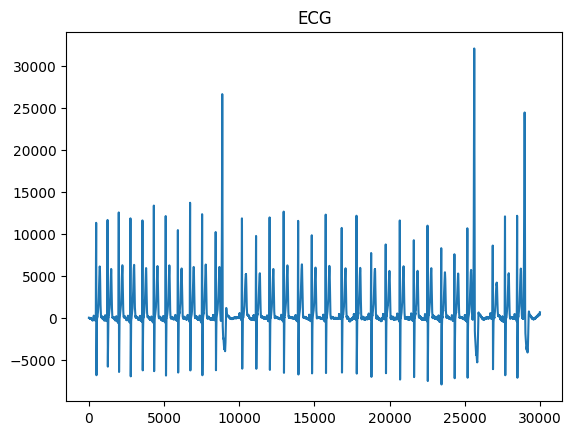

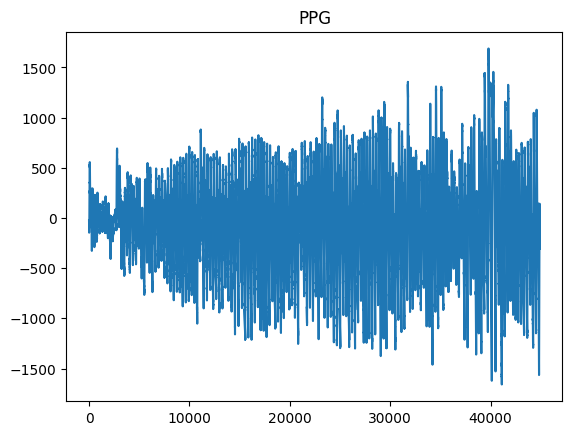

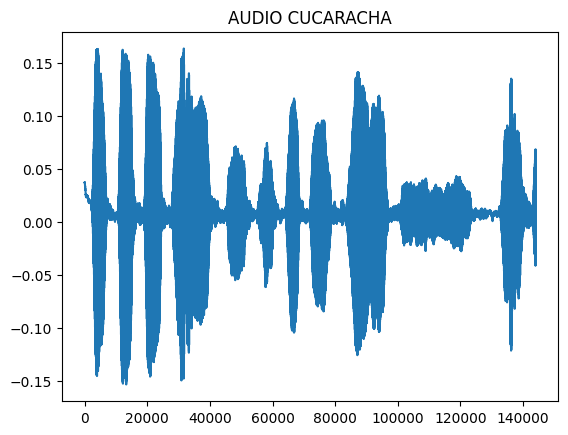

In [7]:
#%% Librerias
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal as sig
import scipy.io as sio
from scipy.io.wavfile import write

####################################
##            ECG                 ##
####################################
ecg_one_lead = np.load('ecg_sin_ruido.npy')
fs_ecg = 1000

####################################
##          PPG sin ruido         ##
####################################

fs_ppg = 400 # Hz
ppg = np.load('ppg_sin_ruido.npy')


####################################
##          CUCARACHA             ##
####################################
fs_audio_cuca, wav_data_cuca = sio.wavfile.read('la cucaracha.wav')


plt.figure()
plt.title('ECG')
plt.plot(ecg_one_lead)


plt.figure()
plt.title('PPG')
plt.plot(ppg)


plt.figure()
plt.title('AUDIO CUCARACHA')
plt.plot(wav_data_cuca)

### Selección de nperseg de cada estimación
Se realizó una inspección visual de cada estimacion, superponiendo difrenetes nperseg. Y de cada señal se selecciono la onfiguracion con una varianza y perdida de resolucion espectral sea razonable.

* **Señal de Audio (Silbido):** 20.000.
* **Señal de ECG:** 7.500.
* **Señal de PPG:** 11.000.

A continuación, se presenta el bloque de código utilizado para importar los datos:

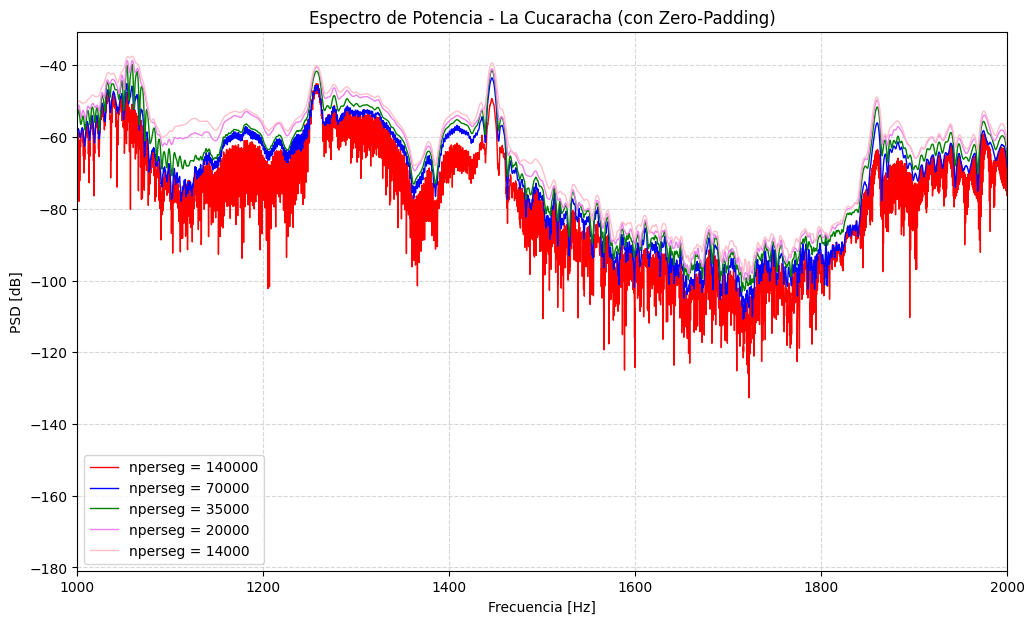

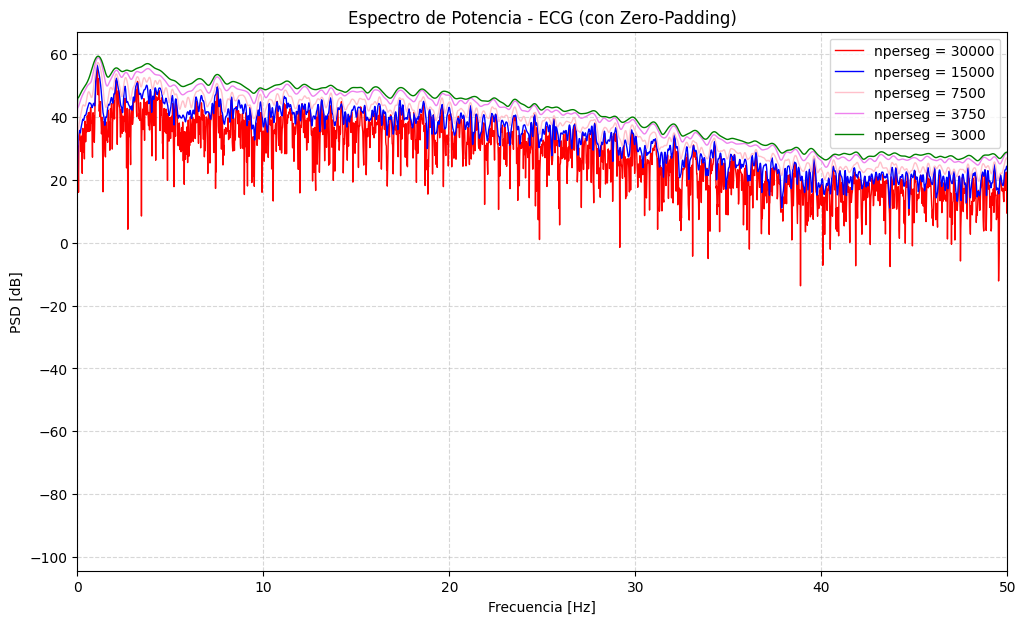

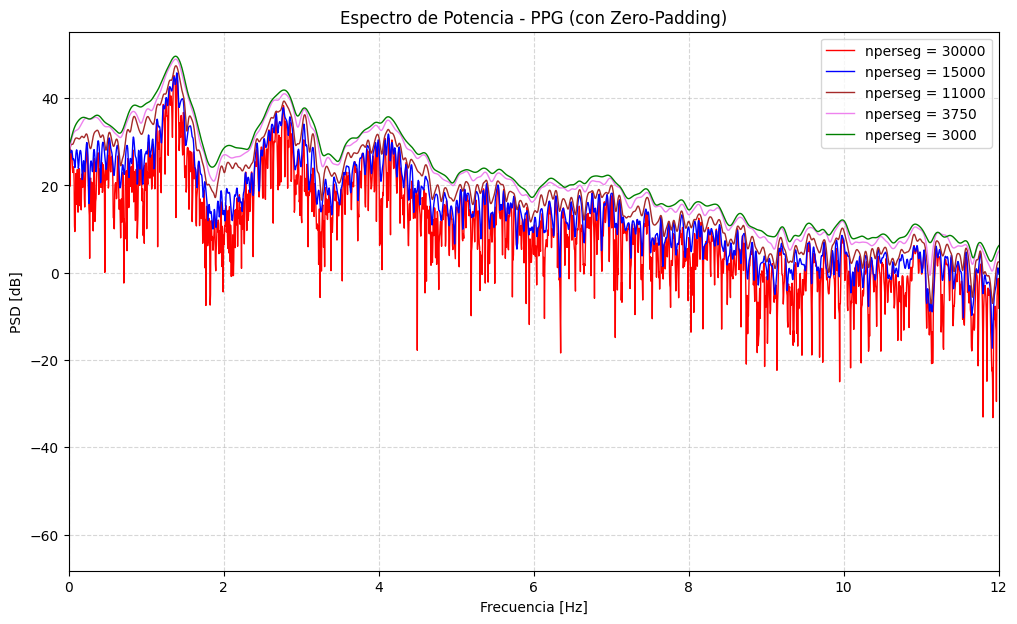

In [11]:

#%%CUCHARCHA 

nn=140000

# Definimos el tamaño del zero-padding. Generalmente es una potencia de 2 mayor a nperseg, 
# o simplemente un multiplicador. 
nfft_pad = nn * 2

f_cuca, Pxx_den_cuca = sig.welch(wav_data_cuca, fs_audio_cuca,window='hamming',scaling='spectrum',nperseg=nn,nfft=nfft_pad)
f_cuca2, Pxx_den_cuca2 = sig.welch(wav_data_cuca, fs_audio_cuca,window='hamming',scaling='spectrum',nperseg=nn/2,nfft=nfft_pad)
f_cuca4, Pxx_den_cuca4 = sig.welch(wav_data_cuca, fs_audio_cuca,window='hamming',scaling='spectrum',nperseg=nn/4,nfft=nfft_pad)
f_cuca8, Pxx_den_cuca8 = sig.welch(wav_data_cuca, fs_audio_cuca,window='hamming',scaling='spectrum',nperseg=nn/7,nfft=nfft_pad)
f_cuca10, Pxx_den_cuca10 = sig.welch(wav_data_cuca, fs_audio_cuca,window='hamming',scaling='spectrum',nperseg=nn/10,nfft=nfft_pad)

# Conversión a dB
pxx_cuca_db = 10 * np.log10(Pxx_den_cuca)
pxx_cuca2_db = 10 * np.log10(Pxx_den_cuca2)
pxx_cuca4_db = 10 * np.log10(Pxx_den_cuca4)
pxx_cuca8_db = 10 * np.log10(Pxx_den_cuca8)
pxx_cuca10_db = 10 * np.log10(Pxx_den_cuca10)


plt.figure(1, figsize=(12, 7))  

plt.plot(f_cuca, pxx_cuca_db, color='red', label=f'nperseg = {nn}', linewidth=1)
plt.plot(f_cuca2, pxx_cuca2_db, color='blue', label=f'nperseg = {nn//2}', linewidth=1)
plt.plot(f_cuca4, pxx_cuca4_db, color='green', label=f'nperseg = {nn//4}', linewidth=1)
plt.plot(f_cuca8, pxx_cuca8_db, color='violet', label=f'nperseg = {nn//7}', linewidth=1)
plt.plot(f_cuca10, pxx_cuca10_db, color='pink', label=f'nperseg = {nn//10}', linewidth=1)
plt.title(f"Espectro de Potencia - La Cucaracha (con Zero-Padding)")
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('PSD [dB]')
plt.xlim([1000, 2000])
plt.legend() # Añadido para mostrar las etiquetas
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.show()

#%%ECG
nn_ecg=30000
nfft_ecg_pad = nn_ecg * 2 # Zero-padding aplicado al ECG

f_ecg, Pxx_den_ecg = sig.welch(ecg_one_lead, fs_ecg,window='hamming',scaling='spectrum',nperseg=nn_ecg,nfft=nfft_ecg_pad)
f_ecg2, Pxx_den_ecg2 = sig.welch(ecg_one_lead, fs_ecg,window='hamming',scaling='spectrum',nperseg=nn_ecg/2,nfft=nfft_ecg_pad)
f_ecg4, Pxx_den_ecg4 = sig.welch(ecg_one_lead, fs_ecg,window='hamming',scaling='spectrum',nperseg=nn_ecg/4,nfft=nfft_ecg_pad)
f_ecg8, Pxx_den_ecg8 = sig.welch(ecg_one_lead, fs_ecg,window='hamming',scaling='spectrum',nperseg=nn_ecg/8,nfft=nfft_ecg_pad)
f_ecg10, Pxx_den_ecg10 = sig.welch(ecg_one_lead, fs_ecg,window='hamming',scaling='spectrum',nperseg=nn_ecg/10,nfft=nfft_ecg_pad)

# Conversión a dB
pxx_ecg_db = 10 * np.log10(Pxx_den_ecg)
pxx_ecg2_db = 10 * np.log10(Pxx_den_ecg2)
pxx_ecg4_db = 10 * np.log10(Pxx_den_ecg4)
pxx_ecg8_db = 10 * np.log10(Pxx_den_ecg8)
pxx_ecg10_db = 10 * np.log10(Pxx_den_ecg10)


plt.figure(2, figsize=(12, 7))

plt.plot(f_ecg, pxx_ecg_db, color='red', label=f'nperseg = {nn_ecg}', linewidth=1)
plt.plot(f_ecg2, pxx_ecg2_db, color='b', label=f'nperseg = {nn_ecg//2}', linewidth=1)
plt.plot(f_ecg4, pxx_ecg4_db, color='pink', label=f'nperseg = {nn_ecg//4}', linewidth=1)
plt.plot(f_ecg8, pxx_ecg8_db, color='violet', label=f'nperseg = {nn_ecg//8}', linewidth=1)
plt.plot(f_ecg10, pxx_ecg10_db, color='green', label=f'nperseg = {nn_ecg//10}', linewidth=1)
plt.title(f"Espectro de Potencia - ECG (con Zero-Padding)")
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('PSD [dB]')
plt.xlim([0, 50])
plt.legend() # Añadido para mostrar las etiquetas
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.show()


#%%PPG sin ruido

nn_ppg=44000
# Definimos el tamaño del zero-padding. Generalmente es una potencia de 2 mayor a nperseg, 
# o simplemente un multiplicador. 
nfft_pad_PPG = nn_ppg * 2

f_PPG, Pxx_den_ppg = sig.welch(ppg, fs_ppg,window='hamming',scaling='spectrum',nperseg=nn_ppg,nfft=nfft_pad_PPG)
f_PPG2, Pxx_den_ppg2 = sig.welch(ppg, fs_ppg,window='hamming',scaling='spectrum',nperseg=nn_ppg/2,nfft=nfft_pad_PPG)
f_PPG4, Pxx_den_ppg4 = sig.welch(ppg, fs_ppg,window='hamming',scaling='spectrum',nperseg=nn_ppg/4,nfft=nfft_pad_PPG)
f_PPG8, Pxx_den_ppg8 = sig.welch(ppg, fs_ppg,window='hamming',scaling='spectrum',nperseg=nn_ppg/8,nfft=nfft_pad_PPG)
f_PPG10, Pxx_den_ppg10 = sig.welch(ppg, fs_ppg,window='hamming',scaling='spectrum',nperseg=nn_ppg/10,nfft=nfft_pad_PPG)



# Conversión a dB
pxx_ppg_db = 10 * np.log10(Pxx_den_ppg)
pxx_ppg2_db = 10 * np.log10(Pxx_den_ppg2)
pxx_ppg4_db = 10 * np.log10(Pxx_den_ppg4)
pxx_ppg8_db = 10 * np.log10(Pxx_den_ppg8)
pxx_ppg10_db = 10 * np.log10(Pxx_den_ppg10)


plt.figure(3, figsize=(12, 7))

plt.plot(f_PPG, pxx_ppg_db, color='red', label=f'nperseg = {nn_ecg}', linewidth=1)
plt.plot(f_PPG2, pxx_ppg2_db, color='b', label=f'nperseg = {nn_ecg//2}', linewidth=1)
plt.plot(f_PPG4, pxx_ppg4_db, color='brown', label=f'nperseg = {nn_ppg//4}', linewidth=1)
plt.plot(f_PPG8, pxx_ppg8_db, color='violet', label=f'nperseg = {nn_ecg//8}', linewidth=1)
plt.plot(f_PPG10, pxx_ppg10_db, color='green', label=f'nperseg = {nn_ecg//10}', linewidth=1)
plt.title(f"Espectro de Potencia - PPG (con Zero-Padding)")
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('PSD [dB]')
plt.xlim([0, 12])
plt.legend() # Añadido para mostrar las etiquetas
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.show()


### Cálculo del Ancho de Banda (BW)

Una vez definidos los parámetros óptimos para la estimación espectral, se procedió a determinar el Ancho de Banda (BW) efectivo de cada registro. Para garantizar la robustez del cálculo, se implementó un algoritmo basado en una doble normalización:

1. **Normalización de Amplitud (Espectro relativo):** En primer lugar, se normalizó la Densidad Espectral de Potencia en escala lineal dividiendo todos los valores por el máximo absoluto de potencia. Al convertir este resultado a decibeles, se fuerza a que el pico de máxima energía de la señal quede posicionado exactamente en **0 dB**. Esto resulta fundamental para establecer umbrales de descarte de ruido coherentes (por ejemplo, truncando a cero toda la energía que se encuentre 40 decibeles por debajo del pico principal).
2. **Normalización de Potencia Acumulada:** Posteriormente, para calcular el BW empírico, se integró (mediante suma acumulada) la potencia lineal filtrada y se dividió el arreglo resultante por la potencia total absoluta. De esta manera, la curva de energía acumulada queda acotada en el rango de 0 a 1, permitiendo identificar de forma algorítmica y directa el índice frecuencial exacto donde la señal concentra el **0.95** (95%) de su energía total.

Banda pasante: de 1015.71 Hz a 1975.20 Hz
Ancho de Banda (BW) al 95%: 959.49 Hz


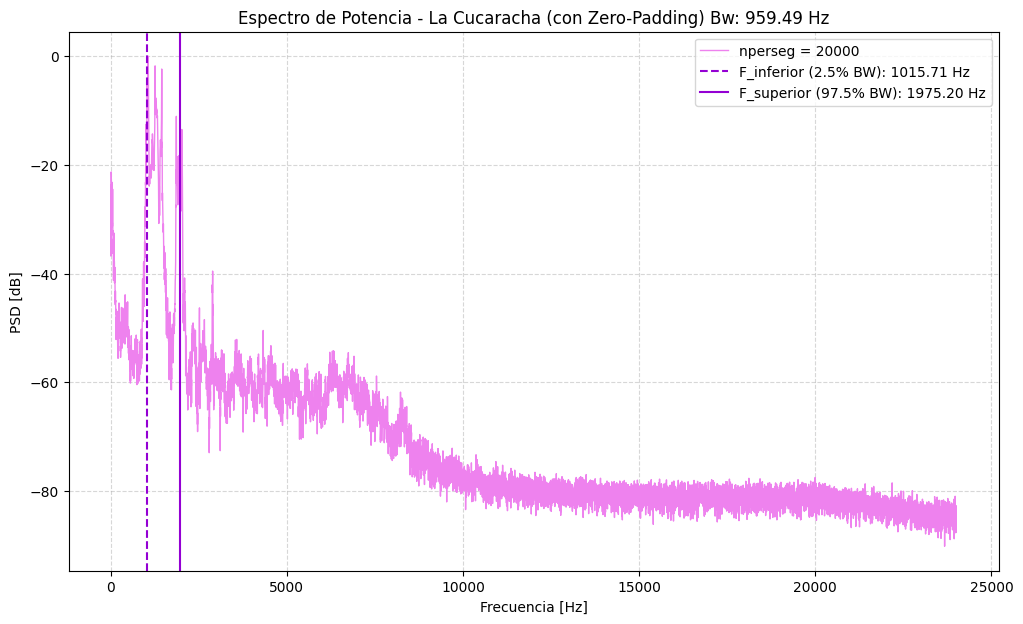

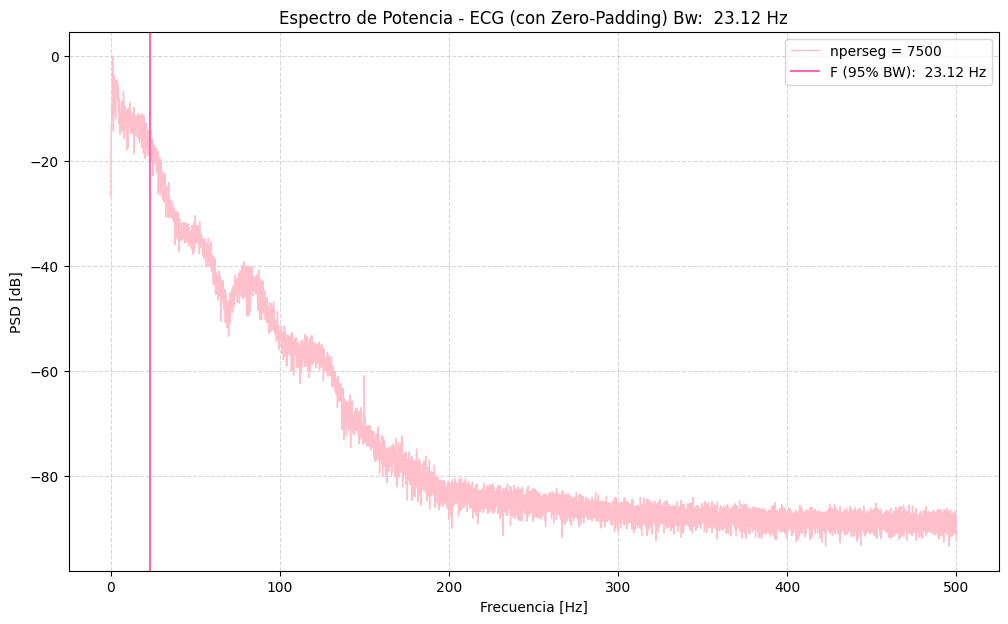

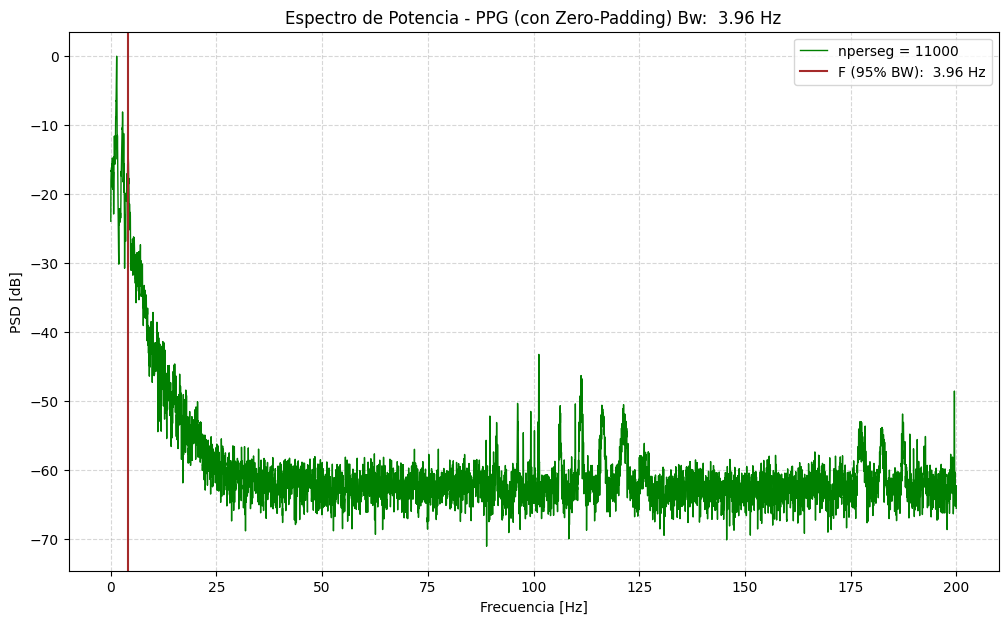

In [13]:
#%%CUCHARCHA 

nn=140000

# Definimos el tamaño del zero-padding. Generalmente es una potencia de 2 mayor a nperseg, 
# o simplemente un multiplicador. 
nfft_pad = nn * 2

f_cuca8, Pxx_den_cuca8 = sig.welch(wav_data_cuca, fs_audio_cuca,window='hamming',scaling='spectrum',nperseg=nn/7,nfft=nfft_pad)

#Normalizacion
Pxx_den_cuca8_norm = Pxx_den_cuca8 / np.max(np.abs(Pxx_den_cuca8))

# Conversión a dB

pxx_cuca8_db_norm = 10 * np.log10(Pxx_den_cuca8_norm)




#Calculo de bw

#Filtrado de Piso de ruido (en lineal, pero usando la máscara normalizada)
umbral_db_audio = -80
psd_filtrado_lineal = np.copy(Pxx_den_cuca8)
psd_filtrado_lineal[pxx_cuca8_db_norm < umbral_db_audio] = 0

potencia_acumulada = np.cumsum(psd_filtrado_lineal)
potencia_total = potencia_acumulada[-1]
potencia_acumulada_norm = potencia_acumulada / potencia_total

indice_inferior = np.where(potencia_acumulada_norm >= 0.025)[0][0]
indice_superior = np.where(potencia_acumulada_norm >= 0.975)[0][0]

# Y para sacar las frecuencias (asumiendo que tenés la variable f_cuca8):
f_cuca_inf = f_cuca8[indice_inferior]
f_cuca_sup = f_cuca8[indice_superior]
bw_efectivo = f_cuca_sup - f_cuca_inf

print(f"Banda pasante: de {f_cuca_inf:.2f} Hz a {f_cuca_sup:.2f} Hz")
print(f"Ancho de Banda (BW) al 95%: {bw_efectivo:.2f} Hz")
plt.figure(1, figsize=(12, 7))  
plt.plot(f_cuca8, pxx_cuca8_db_norm, color='violet', label=f'nperseg = {nn//7}', linewidth=1)
plt.axvline(x=f_cuca_inf, color='darkviolet', linestyle='--', linewidth=1.5, label=f"F_inferior (2.5% BW): {f_cuca_inf:.2f} Hz")
plt.axvline(x=f_cuca_sup, color='darkviolet', linestyle='-', linewidth=1.5, label=f"F_superior (97.5% BW): {f_cuca_sup:.2f} Hz")
plt.title(f"Espectro de Potencia - La Cucaracha (con Zero-Padding) Bw: {bw_efectivo:.2f} Hz")
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('PSD [dB]')
plt.legend() # Añadido para mostrar las etiquetas
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.show()


#%%ECG
nn_ecg=30000
nfft_ecg_pad = nn_ecg * 2 # Zero-padding aplicado al ECG
f_ecg4, Pxx_den_ecg4 = sig.welch(ecg_one_lead, fs_ecg,window='hamming',scaling='spectrum',nperseg=nn_ecg/4,nfft=nfft_ecg_pad)


Pxx_den_ecg4_norm=Pxx_den_ecg4/np.max(np.abs(Pxx_den_ecg4))
# Conversión a dB

pxx_ecg4_db = 10 * np.log10(Pxx_den_ecg4_norm)

#Calculo de Bw
umbral_db_ecg = -80
psd_ecg_filtrado = np.copy(Pxx_den_ecg4)
psd_ecg_filtrado[pxx_ecg4_db < umbral_db_ecg] = 0
potencia_acumulada_ecg = np.cumsum(psd_ecg_filtrado)
potencia_total_ecg = potencia_acumulada_ecg[-1]
potencia_acumulada_ecg_norm = potencia_acumulada_ecg / potencia_total_ecg

#Encontrar el índice donde se alcanza el 95% de la energía
indice_bw_ecg = np.where(potencia_acumulada_ecg_norm >= 0.95)[0][0]

#Buscar a qué frecuencia corresponde ese índice
bw_ecg = f_ecg4[indice_bw_ecg]

plt.figure(2, figsize=(12, 7))

plt.plot(f_ecg4, pxx_ecg4_db, color='pink', label=f'nperseg = {nn_ecg//4}', linewidth=1)
plt.axvline(bw_ecg, color='hotpink', linestyle='-', linewidth=1.5, label=f"F (95% BW): {bw_ecg: .2f} Hz")
plt.title(f"Espectro de Potencia - ECG (con Zero-Padding) Bw: {bw_ecg: .2f} Hz")
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('PSD [dB]')
plt.legend() # Añadido para mostrar las etiquetas
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.show()

#%%PPG sin ruido

nn_ppg=44000
# Definimos el tamaño del zero-padding. Generalmente es una potencia de 2 mayor a nperseg, 
# o simplemente un multiplicador. 
nfft_pad_PPG = nn_ppg * 2

f_PPG, Pxx_den_ppg = sig.welch(ppg, fs_ppg,window='hamming',scaling='spectrum',nperseg=nn_ppg,nfft=nfft_pad_PPG)
f_PPG2, Pxx_den_ppg2 = sig.welch(ppg, fs_ppg,window='hamming',scaling='spectrum',nperseg=nn_ppg/2,nfft=nfft_pad_PPG)
f_PPG4, Pxx_den_ppg4 = sig.welch(ppg, fs_ppg,window='hamming',scaling='spectrum',nperseg=nn_ppg/4,nfft=nfft_pad_PPG)
f_PPG8, Pxx_den_ppg8 = sig.welch(ppg, fs_ppg,window='hamming',scaling='spectrum',nperseg=nn_ppg/8,nfft=nfft_pad_PPG)
f_PPG10, Pxx_den_ppg10 = sig.welch(ppg, fs_ppg,window='hamming',scaling='spectrum',nperseg=nn_ppg/10,nfft=nfft_pad_PPG)


Pxx_den_PPG_norm=Pxx_den_ppg4/np.max(np.abs(Pxx_den_ppg4))
# Conversión a dB

pxx_ppg4_db = 10 * np.log10(Pxx_den_PPG_norm)

#Calculo de Bw
umbral_db_ppg = -40
psd_ppg_filtrado = np.copy(Pxx_den_ppg4)
psd_ppg_filtrado[pxx_ppg4_db < umbral_db_ppg] = 0
potencia_acumulada_ppg = np.cumsum(psd_ppg_filtrado)
potencia_total_ppg = potencia_acumulada_ppg[-1]
potencia_acumulada_ppg_norm = potencia_acumulada_ppg / potencia_total_ppg

#Encontrar el índice donde se alcanza el 95% de la energía
indice_bw_ppg = np.where(potencia_acumulada_ppg_norm >= 0.95)[0][0]

#Buscar a qué frecuencia corresponde ese índice
bw_ppg = f_PPG4[indice_bw_ppg]

plt.figure(3, figsize=(12, 7))
plt.plot(f_PPG4, pxx_ppg4_db, color='green', label=f'nperseg = {nn_ppg//4}', linewidth=1)
plt.axvline(bw_ppg, color='brown', linestyle='-', linewidth=1.5, label=f"F (95% BW): {bw_ppg: .2f} Hz")
plt.title(f"Espectro de Potencia - PPG (con Zero-Padding) Bw: {bw_ppg: .2f} Hz")
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('PSD [dB]')
plt.legend() # Añadido para mostrar las etiquetas
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.show()

## Conclusiones y Resumen de Resultados

A partir del procesamiento digital realizado mediante el método de Welch y el algoritmo de normalización de potencia, se obtuvieron los anchos de banda efectivos (al 95% de la energía útil) para cada una de las señales analizadas. Los resultados se resumen en la siguiente tabla:

| Señal Analizada | Comportamiento Espectral | Ancho de Banda (BW al 95%) |
| :--- | :--- | :--- |
| **Pletismografía (PPG)** | Pasa-bajos | 3.96 Hz |
| **Electrocardiograma (ECG)** | Pasa-bajos | 23.12 Hz |
| **Audio (Silbido)** | Pasa-banda | 959.49 Hz |

---

### Análisis Fisiológico y Físico de los Resultados

* **Señal PPG (3.96 Hz):** El resultado obtenido es altamente coherente con la naturaleza hemodinámica de la señal. La pletismografía óptica registra el pulso volumétrico de la sangre, cuya frecuencia fundamental está dada por la frecuencia cardíaca (típicamente entre 1 y 2 Hz en reposo). Un ancho de banda cercano a los 4 Hz confirma que casi toda la energía reside en esa oscilación principal y en sus primeros armónicos, los cuales son responsables de darle la forma suave y ondulada característica a la señal (pico sistólico y onda dicrótica).
* **Señal ECG (23.12 Hz):** A diferencia de la señal vascular, el electrocardiograma registra la actividad eléctrica directa del corazón. Eventos como el complejo QRS (despolarización de los ventrículos) presentan transiciones de voltaje mucho más abruptas y agudas en el tiempo temporal, lo que matemáticamente exige un mayor contenido de altas frecuencias en el espectro. El valor de 23.12 Hz concuerda perfectamente con la literatura clínica, que establece que la mayor parte de la información diagnóstica de un ECG estándar se ubica por debajo de los 30 a 40 Hz.
* **Señal de Audio (959.49 Hz):** Al tratarse de un silbido humano, cuyo rango natural es: 500 Hz a 2.000 Hz. El ancho de banda de aproximadamente 960 Hz captura a la perfección la excursión frecuencial de las notas fundamentales de la melodía ("La Cucaracha").

**Conclusión Metodológica:**
El desarrollo de este trabajo práctico permitió comprobar la eficacia de los estimadores no paramétricos para caracterizar señales físicas. La correcta configuración del método de Welch (balanceando varianza y resolución mediante la elección de la ventana y los segmentos), combinada con el zero-padding y la técnica de suma de potencia normalizada, demostró ser una herramienta sumamente robusta para automatizar el cálculo del ancho de banda efectivo.